In [1]:
from langchain_ollama import ChatOllama
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.agents import create_agent

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
tavily_api_key = os.getenv("TAVILY_API_KEY")


In [3]:
llm = ChatOllama(
    model="llama3.1",
    temperature=0.7,
)

In [34]:
tavily_search = TavilySearchResults(maxresults=5)

In [35]:
from langchain_core.tools import tool
from datetime import datetime

@tool
def get_current_date():
    """ Returnerer dagens dato og tid. Brukes av alle tidsrelaterte spørsmål. """
    return f"Dagens dato er: {datetime.now().strftime('%d %B %Y')}"

In [6]:
tools = [tavily_search, get_current_date]

In [36]:
graph = create_agent(llm, tools)

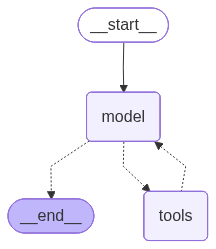

In [37]:
from IPython.display import  display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
from IPython.display import Markdown, display
def render_markdown(text):
    display(Markdown(text))


In [44]:
# streamer agentens svar i sanntid
def process_stream(stream):
    message = None
    for s in stream:
        print(f"Stream output: {s}")  # Debug
        if "messages" in s:
            messages = s["messages"]
            if isinstance(messages, list) and len(messages) > 0:
                message = messages[-1]
                if hasattr(message, 'pretty_print'):
                    message.pretty_print()
    return message

In [40]:
# function for å prosessere query
def process_query(query):
    inputs = {"messages":[("user", query)]}
    message = process_stream(graph.stream(inputs))
    if message and hasattr(message, 'content'):
        render_markdown(f"## Svaret er: \n{message.content}")
    else:
        print("Feil: Kunne ikke hente svar fra agenten")

In [45]:
process_query("Hvordan er været i Oslo nå?")

Stream output: {'model': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-05-13T13:05:40.88888Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2524537166, 'load_duration': 136296250, 'prompt_eval_count': 234, 'prompt_eval_duration': 1140307333, 'eval_count': 26, 'eval_duration': 1232378293, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--019e2171-5e38-7ae1-9d26-f4701ab030f4-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'været i Oslo nå'}, 'id': '82db98a4-a41e-4a16-b0dc-2440bcab54d5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 234, 'output_tokens': 26, 'total_tokens': 260})]}}
Stream output: {'tools': {'messages': [ToolMessage(content='[{"title": "Været i Oslo neste 14 dagene - Langtidsvarslet", "url": "https://www.vaeret1.com/europe/norway/eastern-norway/oslo?page=14", "content": "Været i Oslo\\n\\nLangtidsvars